## Imports


In [232]:
!pip install brian2
from brian2 import *
from utils import *
import numpy as np

start_scope()

## passive channel Bipolar neuron


In [233]:
length_thin = 200 *um
diameter_thin = 2 *um
compartments_thin = 0.05 * length_thin /um

# # Morphology
# morpho = Soma(20*um)
# morpho.L = Cylinder(diameter=diameter_thin, length=length_thin, n=compartments_thin)
# morpho.R = Cylinder(diameter=diameter_thin, length=length_thin, n=compartments_thin)
#
# # Passive channels
# gL = 1e-4*siemens/cm**2
# EL = -70*mV
# Es = 0*mV
# eqs='''
# Im = gL*(EL-v) : amp/meter**2
# Is = (gs_L + gs_R) * (Es-v) : amp (point current)
# gs_L : siemens
# gs_R : siemens
# '''
#
# bipolar_neuron = SpatialNeuron(
#     morphology=morpho,
#     model=eqs,
#     Cm=1*uF/cm**2,
#     Ri=200*ohm*cm,
#     method='exponential_euler'
# )
# neuron.v = EL

In [234]:
n_comp=11
lambda_um=200
left_comp_index=None
right_comp_index=None
plot=False
threshold=-55.0

# Key morphology
lambda_ = lambda_um * um
compartment_length = 0.05 * lambda_
dend_length = n_comp * compartment_length
diameter = 2 * um  # From paper

morpho = Soma(diameter=20 * um)
morpho.L = Cylinder(length=dend_length, diameter=diameter, n=n_comp)
morpho.R = Cylinder(length=dend_length, diameter=diameter, n=n_comp)

# show()

eqs = """
Im = gl * (El - v) + gsyn*(Esyn-v) : amp/meter**2
dgsyn/dt = -gsyn / tau_syn : siemens/meter**2
gl : siemens/meter**2
El : volt
Esyn : volt
tau_syn : second (shared)
"""

neuron = SpatialNeuron(
    morphology=morpho,
    model=eqs,
    threshold=f"v > {threshold}*mV",
    threshold_location=0,
    reset="v = -65*mV",
    refractory="2*ms",
    Cm=1 * uF / cm**2,
    Ri=200 * ohm * cm,
    method="exponential_euler",
)

neuron.v = -65 * mV
# neuron.gl = 0.0005*siemens/cm**2
neuron.gl = (
    0.008 * siemens / cm**2
)  # TODO play with this, this influences threshold crossing!
neuron.El = -62.5 * mV
neuron.gsyn = 0 * siemens / cm**2
neuron.Esyn = 0 * mV
neuron.tau_syn = 0.5 * ms
w_syn = 14 * nS  # (14-26 in paper)


## Generate input trains

In [235]:
N=6
f_stim_Hz= 500
f_pre_Hz=350
tmax_ms=10
jitter_ms=0
itd_ms = 0.525 # for 90 deg



left_i, left_t = binomial_spike_train(
    N, f_stim_Hz, f_pre_Hz, tmax_ms, phase=0, jitter_ms=jitter_ms
)
right_i, right_t = binomial_spike_train(
    N, f_stim_Hz, f_pre_Hz, tmax_ms, phase=itd_ms, jitter_ms=jitter_ms
)

print(f"Left spikes: {left_i} at time {left_t}")
print(f"Right spikes: {right_i} at time {right_t}")

# Shift times if negative
all_times = np.concatenate([left_t, right_t])
min_time = np.min(all_times)
if min_time < 0:
    left_t, right_t = left_t - min_time, right_t - min_time
    tmax_ms = tmax_ms - min_time


input_left = SpikeGeneratorGroup(N, left_i, left_t * ms)
input_right = SpikeGeneratorGroup(N, right_i, right_t * ms)




Left spikes: [0, 1, 2, 3, 4, 5, 0, 1, 2, 4, 5, 1, 2, 3, 4, 5, 1, 4, 0, 1, 4, 5] at time [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 2.0, 2.0, 2.0, 2.0, 4.0, 4.0, 4.0, 4.0, 4.0, 6.0, 6.0, 8.0, 8.0, 8.0, 8.0]
Right spikes: [0, 2, 4, 5, 0, 1, 2, 0, 1, 2, 3, 4, 1, 2, 3, 4, 5, 0, 3, 5] at time [0.525, 0.525, 0.525, 0.525, 2.525, 2.525, 2.525, 4.525, 4.525, 4.525, 4.525, 4.525, 6.525, 6.525, 6.525, 6.525, 6.525, 8.525, 8.525, 8.525]


### plot sound wave function
 (not accurate just for fun and looking at phase-shift)

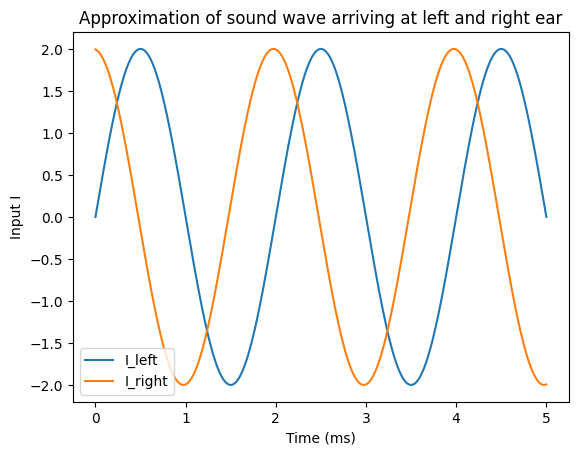

In [236]:
t_ms = np.linspace(0, 5, 1000)  # time i ms for plot

t_sec = t_ms/1000               # time in ms for I
A = 2

def I(A , f , phase_shift=0):
    # A = amplitude , f = frequency in Hz, phase_shift = phase_shift in ms
    return A * sin(2 * pi * f  * (t_sec +  phase_shift/1000) )

I_left = I(A, f_stim_Hz, 0)
I_right = I(A, f_stim_Hz, phase_shift=itd_ms)


plt.plot(t_ms, I_left, label="I_left")
plt.plot(t_ms, I_right, label="I_right")
plt.xlabel('Time (ms)')
plt.ylabel('Input I')
plt.title('Approximation of sound wave arriving at left and right ear')
plt.legend()
plt.show()

## Connecting the input to the bipolar neuron

In [237]:
# Compartment centers (for info/indices)
compartment_centers = np.linspace(
    compartment_length / 2, dend_length - compartment_length / 2, n_comp
)
syn_dist = 0.1 * lambda_  # 0.1 lambda as in paper

# Defaults: closest to 0.1 lambda in each dendrite
default_left = 1 + np.argmin(np.abs(compartment_centers - syn_dist))
default_right = n_comp + 1 + np.argmin(np.abs(compartment_centers - syn_dist))
left_index = default_left if left_comp_index is None else left_comp_index
right_index = default_right if right_comp_index is None else right_comp_index


 # Synapse connections
syn_left = Synapses(
    input_left,
    bipolar_neuron,
    on_pre="gsyn_post += w_syn / area_post")

syn_right = Synapses(
    input_right,
    bipolar_neuron,
    on_pre="gsyn_post += w_syn / area_post")

syn_left.connect(i=range(N), j=left_index)
syn_right.connect(i=range(N), j=right_index)

WARNING    'synapses_3' has been included in the network but not the object on which it depends.Setting 'synapses_3' to inactive. [brian2.core.magic.dependency_warning]
WARNING    'synapses_2' has been included in the network but not the object on which it depends.Setting 'synapses_2' to inactive. [brian2.core.magic.dependency_warning]


[INFO] n_comp=11, lambda=200 um, dendrite length=110.0 um, left_index=2, right_index=13
Max soma voltage: -62.49999996697543 mV
Soma did NOT spike.


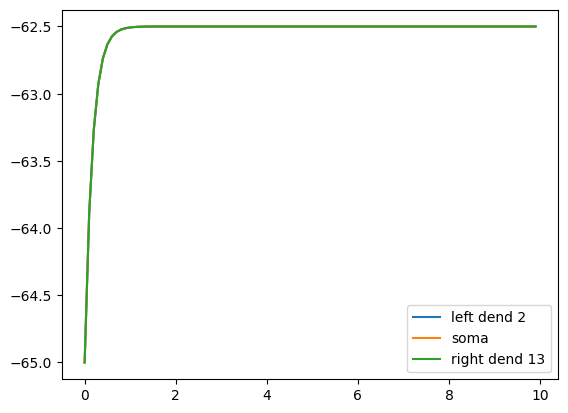

In [238]:
M = StateMonitor(neuron, "v", record=True)
spikemon = SpikeMonitor(neuron)

run(tmax_ms * ms)

print(
    f"[INFO] n_comp={n_comp}, lambda={lambda_um} um, dendrite length={dend_length/um:.1f} um, left_index={left_index}, right_index={right_index}"
)
all_v = M.v[0] / mV
max_v = np.max(M.v[0] / mV)
print("Max soma voltage:", max_v, "mV")
if spikemon.count[0] > 0:
    print("Spike times (ms):", spikemon.t / ms)
else:
    print("Soma did NOT spike.")


plt.plot(M.t / ms, M.v[left_index] / mV, label=f"left dend {left_index}")
plt.plot(M.t / ms, M.v[0] / mV, label="soma")
plt.plot(M.t / ms, M.v[right_index] / mV, label=f"right dend {right_index}")
plt.legend()